In [1]:
import pandas as pd
df=pd.read_csv(r"C:\Users\siddh\OneDrive\Desktop\sc_git_demo\movies.csv")
# Step 1: Convert to string
clean = df["released"].astype(str)

# Step 2: Remove country part
clean = clean.str.replace(r"\s*\(.*\)", "", regex=True)

# Step 3: Add day = 1 where missing (no comma → no day)
mask = ~clean.str.contains(",") & (clean != "nan")
clean.loc[mask] = clean.loc[mask] + " 1"

# Step 4: Convert to datetime
df["clean_date"] = pd.to_datetime(clean, format="mixed", errors="coerce")

# Step 5: Extract
df["release_month"] = df["clean_date"].dt.month
df["release_day"] = df["clean_date"].dt.day
df=df[df["country"]=="United States"]
df["roi"] = df["gross"] / df["budget"]
bins = [0, 0.5, 1, 2, float("inf")]
labels = ["flop", "below_avg", "hit", "blockbuster"]
df=df.drop("clean_date", axis=1)
df["roi_class"] = pd.cut(df["roi"], bins=bins, labels=labels)
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,release_month,release_day,roi,roi_class
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0,7.0,2.0,13.078468,blockbuster
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0,6.0,20.0,29.909726,blockbuster
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0,7.0,2.0,23.843868,blockbuster
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0,7.0,25.0,6.641057,blockbuster
5,Friday the 13th,R,Horror,1980,"May 9, 1980 (United States)",6.4,123000.0,Sean S. Cunningham,Victor Miller,Betsy Palmer,United States,550000.0,39754601.0,Paramount Pictures,95.0,5.0,9.0,72.281093,blockbuster


In [2]:
missing = df.isnull().sum()
pct = (missing / len(df) * 100).round(1)
 
summary = pd.DataFrame({
    "missing_rows": missing,
    "percentage":   pct
}).sort_values("missing_rows", ascending=False)
 
print(summary.to_string())

               missing_rows  percentage
roi_class              1149        21.0
roi                    1149        21.0
budget                 1099        20.1
gross                    98         1.8
rating                   18         0.3
company                  12         0.2
votes                     3         0.1
score                     3         0.1
runtime                   2         0.0
genre                     0         0.0
name                      0         0.0
country                   0         0.0
star                      0         0.0
writer                    0         0.0
director                  0         0.0
year                      0         0.0
released                  0         0.0
release_day               0         0.0
release_month             0         0.0


In [3]:
df.to_excel("movies_cleaned.xlsx")

In [4]:
df[["budget", "roi"]].corr().round(2)

,budget,roi
budget,1.00,-0.02
roi,-0.02,1.00


In [5]:
# Order
order = ["Low", "Mid", "High", "Very High"]

# --- IQR Capping ---
Q1 = df["roi"].quantile(0.25)
Q3 = df["roi"].quantile(0.75)
IQR = Q3 - Q1

lower_cap = Q1 - 1.5 * IQR
upper_cap = Q3 + 1.5 * IQR
df["budget_bucket"] = pd.qcut(df["budget"], q=4, labels=["low", "mid", "high", "very_high"])
df["roi_capped"] = df["roi"].clip(lower=lower_cap, upper=upper_cap)
df["budget_bucket"] = pd.qcut(df["budget"], q=4, labels=["low", "mid", "high", "very_high"])
df["roi_capped"] = df["roi"].clip(lower=lower_cap, upper=upper_cap)

df["budget_bucket"] = pd.qcut(df["budget"], q=4, labels=["low", "mid", "high", "very_high"])
df.groupby("budget_bucket")["roi_capped"].quantile([0.25, 0.5, 0.75]).unstack()

C:\Users\siddh\AppData\Local\Temp\ipykernel_28968\3168917902.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("budget_bucket")["roi_capped"].quantile([0.25, 0.5, 0.75]).unstack()


,0.25,0.50,0.75
budget_bucket,,,
low,0.614643,2.058782,5.404698
mid,0.616264,1.664536,3.499576
high,0.726999,1.680543,3.303858
very_high,1.325279,2.296787,3.670503


C:\Users\siddh\AppData\Local\Temp\ipykernel_28968\1570715172.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\siddh\AppData\Local\Temp\ipykernel_28968\1570715172.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quartiles = df.groupby("budget_bucket")["roi_capped"].quantile([0.25, 0.5, 0.75]).unstack().reindex(order)


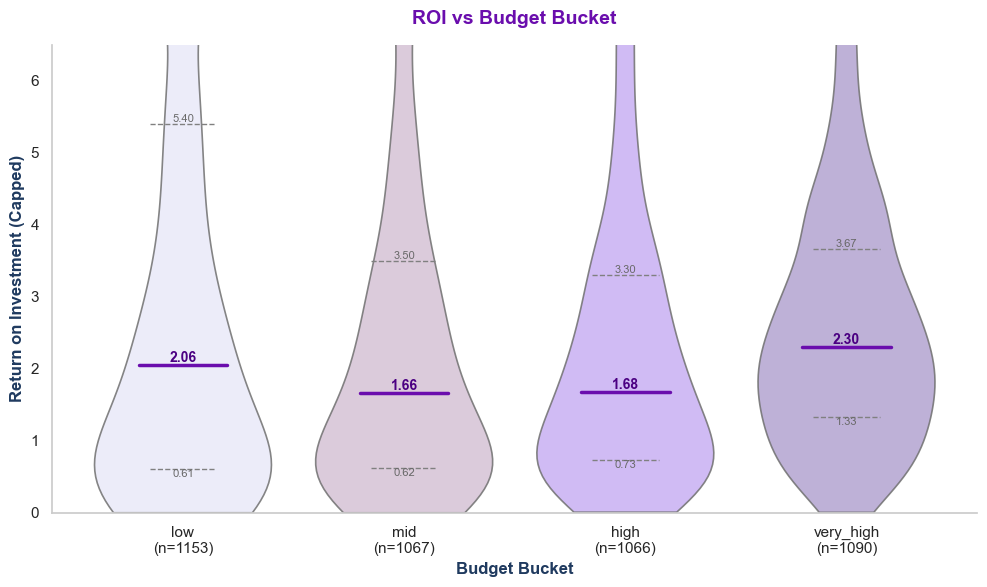

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Style (clean + modern) ---
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12
})

# Order
order = ["low", "mid", "high", "very_high"]

# --- IQR Capping ---
Q1 = df["roi"].quantile(0.25)
Q3 = df["roi"].quantile(0.75)
IQR = Q3 - Q1

lower_cap = Q1 - 1.5 * IQR
upper_cap = Q3 + 1.5 * IQR
df["budget_bucket"] = pd.qcut(df["budget"], q=4, labels=["low", "mid", "high", "very_high"])

df["roi_capped"] = df["roi"].clip(lower=lower_cap, upper=upper_cap)

# --- Counts ---
counts = df["budget_bucket"].value_counts().reindex(order)
labels_with_counts = [f"{b}\n(n={counts[b]})" for b in order]

# --- Pastel palette (Accenture-inspired purples/blues) ---
palette = ["#E6E6FA", "#D8BFD8", "#C5A3FF", "#B19CD9"]  # soft lavender shades

# --- Plot ---
plt.figure(figsize=(10,6))

sns.violinplot(
    x="budget_bucket",
    y="roi_capped",
    data=df,
    order=order,
    inner=None,
    cut=0,
    palette=palette,
    linewidth=1.2
)

# Slight transparency for depth
for violin in plt.gca().collections:
    violin.set_alpha(0.85)

# --- TRUE Quartiles ---
quartiles = df.groupby("budget_bucket")["roi_capped"].quantile([0.25, 0.5, 0.75]).unstack().reindex(order)

for i, bucket in enumerate(order):
    q1, median, q3 = quartiles.loc[bucket]

    # Median (Accenture purple)
    plt.plot([i-0.2, i+0.2], [median, median], color='#6A0DAD', linewidth=2.5)

    # Q1 & Q3 (soft grey)
    plt.plot([i-0.15, i+0.15], [q1, q1], color='gray', linestyle='--', linewidth=1)
    plt.plot([i-0.15, i+0.15], [q3, q3], color='gray', linestyle='--', linewidth=1)

    # Labels
    plt.text(i, median, f"{median:.2f}", ha='center', va='bottom', color='#4B0082', fontsize=10, weight='bold')
    plt.text(i, q1, f"{q1:.2f}", ha='center', va='top', fontsize=8, color='dimgray')
    plt.text(i, q3, f"{q3:.2f}", ha='center', va='bottom', fontsize=8, color='dimgray')

# --- Axis styling ---
plt.xticks(ticks=range(len(order)), labels=labels_with_counts)
plt.ylim(0, 6.5)
plt.yticks([0,1,2,3,4,5,6])

# --- Axis label styling (Accenture-inspired) ---
accent_purple = "#6A0DAD"   # Accenture purple
dark_blue = "#1F3A5F"       # deep consulting blue
plt.title("ROI vs Budget Bucket", color=accent_purple,weight='bold', pad=15)
plt.xlabel("Budget Bucket", color=dark_blue, weight='bold')
plt.ylabel("Return on Investment (Capped)", color=dark_blue, weight='bold')
# Clean spines
sns.despine(left=False, bottom=False)
plt.grid(False)
plt.tight_layout()
plt.show()

In [8]:
df.groupby("genre").agg(
    movie_count=("name", "count"),
    median_roi=("roi", "median")
).sort_values(by="movie_count", ascending=False)

,movie_count,median_roi
genre,,
Comedy,1803,1.867359
Action,1298,1.893062
Drama,902,1.815522
Crime,380,1.408240
Adventure,277,2.090370
Biography,252,1.560683
Horror,246,3.220880
Animation,237,3.229358
Fantasy,34,2.617178


In [27]:
print(df["year"].unique())
print(df_grouped.groupby("year").size().head())

[1980 1981 1982 1983 1984 1985 1986 1987 1988 1989 1990 1991 1992 1993
 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005 2006 2007
 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020]
year
1980     8
1981     8
1982    11
1983    10
1984     8
dtype: int64


C:\Users\siddh\AppData\Local\Temp\ipykernel_16640\3777602853.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\siddh\AppData\Local\Temp\ipykernel_16640\3777602853.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\siddh\AppData\Local\Temp\ipykernel_16640\3777602853.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\siddh\AppData\Local\Temp\ipykernel_16640\3777602853.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `h

C:\Users\siddh\AppData\Local\Temp\ipykernel_16640\3777602853.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


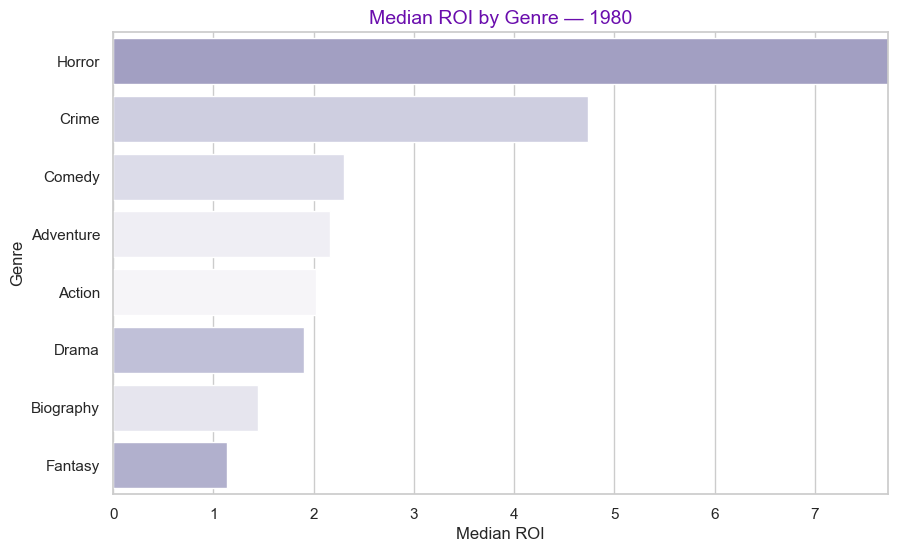

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# from matplotlib.animation import FuncAnimation
# from IPython.display import HTML

# df_copy = df.copy().dropna(subset=["year", "genre", "roi"])

# df_grouped = (
#     df_copy.groupby(["year", "genre"])["roi"]
#     .median()
#     .reset_index()
# )

# # --- Create consistent color mapping ---
# genres = df_grouped["genre"].unique()
# palette = sns.color_palette("Purples", len(genres))

# color_map = dict(zip(genres, palette))

# years = sorted(df_grouped["year"].unique())

# fig, ax = plt.subplots(figsize=(10,6))

# def update(year):
#     ax.clear()

#     data = df_grouped[df_grouped["year"] == year]

#     # 🔥 Sort descending
#     data = data.sort_values("roi", ascending=False).head(10)

#     sns.barplot(
#         x="roi",
#         y="genre",
#         data=data,
#         palette=[color_map[g] for g in data["genre"]],
#         ax=ax
#     )

#     ax.set_title(f"Median ROI by Genre — {int(year)}",
#                  fontsize=14, color="#6a0dad")

#     ax.set_xlabel("Median ROI")
#     ax.set_ylabel("Genre")

#     # Keep axis stable
#     ax.set_xlim(0, df_grouped["roi"].quantile(0.95))

# # --- Animate ---
# anim = FuncAnimation(fig, update, frames=years, interval=800)

# HTML(anim.to_jshtml())

In [44]:
import pandas as pd
import numpy as np
import plotly.express as px
from dash import Dash, dcc, html, Input, Output

# -----------------------------
# DATA PREP
# -----------------------------
df_copy = df.copy().dropna(subset=["year", "genre", "roi", "budget"])

top_genres = df_copy["genre"].value_counts().head(8).index
df_filtered = df_copy[df_copy["genre"].isin(top_genres)]

df_grouped = (
    df_filtered.groupby(["year", "genre"])
    .agg(
        roi_median=("roi", "median"),
        movie_count=("genre", "count"),
        budget_median=("budget", "median")
    )
    .reset_index()
)

# smoothing
df_grouped["roi_smooth"] = df_grouped.groupby("genre")["roi_median"].transform(lambda x: x.rolling(3,1).mean())
df_grouped["count_smooth"] = df_grouped.groupby("genre")["movie_count"].transform(lambda x: x.rolling(3,1).mean())
df_grouped["budget_smooth"] = df_grouped.groupby("genre")["budget_median"].transform(lambda x: x.rolling(3,1).mean())

years = sorted(df_grouped["year"].unique())

# -----------------------------
# FIGURE FUNCTION
# -----------------------------
def create_figure(metric, highlight_genre=None, year_range=None, selected_years=None):
    data = df_grouped.copy()

    if year_range:
        data = data[(data["year"] >= year_range[0]) & (data["year"] <= year_range[1])]

    if selected_years:
        data = data[data["year"].isin(selected_years)]

    if metric == "roi":
        y_col = "roi_smooth"
        y_label = "Median ROI"
    elif metric == "count":
        y_col = "count_smooth"
        y_label = "Number of Movies"
    else:
        y_col = "budget_smooth"
        y_label = "Median Budget"

    fig = px.line(
        data,
        x="year",
        y=y_col,
        color="genre",
        markers=True,
        color_discrete_sequence=px.colors.qualitative.Set2
    )

    # highlight styling
    for trace in fig.data:
        if highlight_genre is None:
            trace.opacity = 0.7
            trace.line.width = 2
        else:
            if trace.name == highlight_genre:
                trace.opacity = 1
                trace.line.width = 5
                trace.line.color = "#A100FF"
                trace.marker.color = "#A100FF"
            else:
                trace.opacity = 0.15
                trace.line.width = 1
                trace.line.color = "#D3D3D3"
                trace.marker.color = "#D3D3D3"

    fig.update_traces(
        hovertemplate=
        "<b>%{fullData.name}</b><br>" +
        "Year: %{x}<br>" +
        f"{y_label}: %{{y:.2f}}<extra></extra>"
    )

    fig.update_layout(
        title=f"{y_label} by Genre Over Time",
        title_font=dict(size=16, color="#A100FF"),
        xaxis_title="Year",
        yaxis_title=y_label,
        hovermode="closest",
        plot_bgcolor="#F7F7F7",
        paper_bgcolor="#F7F7F7"
    )

    return fig


# -----------------------------
# DASH APP
# -----------------------------
app = Dash(__name__)

app.layout = html.Div([
    html.H2("Genre Analytics Dashboard", style={"color": "#A100FF"}),

    dcc.Dropdown(
        id="metric-dropdown",
        options=[
            {"label": "Median ROI", "value": "roi"},
            {"label": "Number of Movies", "value": "count"},
            {"label": "Median Budget", "value": "budget"}
        ],
        value="roi",
        clearable=False,
        style={"width": "300px"}
    ),

    dcc.Dropdown(
        id="year-dropdown",
        options=[{"label": str(y), "value": y} for y in years],
        value=None,
        multi=True,
        placeholder="Select specific years (optional)",
        style={"width": "400px", "marginTop": "10px"}
    ),

    dcc.RangeSlider(
        id="year-slider",
        min=min(years),
        max=max(years),
        step=1,
        value=[min(years), max(years)],
        marks={int(y): str(int(y)) for y in years[::5]}
    ),

    dcc.Graph(
        id="graph",
        figure=create_figure("roi"),
        clear_on_unhover=True
    )
])


# -----------------------------
# CALLBACK (FINAL FIXED)
# -----------------------------
@app.callback(
    Output("graph", "figure"),
    Input("graph", "hoverData"),
    Input("year-slider", "value"),
    Input("metric-dropdown", "value"),
    Input("year-dropdown", "value")
)
def update_graph(hoverData, year_range, metric, selected_years):

    highlight = None

    # Create base figure first
    base_fig = create_figure(metric, None, year_range, selected_years)

    if hoverData:
        curve_idx = hoverData["points"][0]["curveNumber"]

        # Safe mapping from trace index → genre
        if curve_idx < len(base_fig.data):
            highlight = base_fig.data[curve_idx].name

    return create_figure(metric, highlight, year_range, selected_years)


# -----------------------------
# RUN
# -----------------------------
if __name__ == "__main__":
    app.run(debug=True)

In [47]:
import pandas as pd
import numpy as np
import plotly.express as px
from dash import Dash, dcc, html, Input, Output

# -----------------------------
# DATA PREP
# -----------------------------
df_copy = df.copy().dropna(subset=["year", "star", "director", "gross", "roi"])

# Create 5-year bins
df_copy["year_bin"] = (df_copy["year"] // 5) * 5

years = sorted(df_copy["year"].unique())

# -----------------------------
# AGG FUNCTION
# -----------------------------
def get_top_entities(data, entity, metric, top_n):
    
    group_col = "star" if entity == "actor" else "director"

    agg = data.groupby(group_col).agg(
        total_movies=("year", "count"),
        total_gross=("gross", "sum"),
        median_roi=("roi", "median")
    ).reset_index()

    if metric == "movies":
        agg = agg.sort_values("total_movies", ascending=False)
    elif metric == "gross":
        agg = agg.sort_values("total_gross", ascending=False)
    else:
        agg = agg.sort_values("median_roi", ascending=False)

    return agg.head(top_n)[group_col].tolist()


# -----------------------------
# FIGURE FUNCTION
# -----------------------------
def create_figure(entity, metric, top_n, year_range, highlight=None):

    data = df_copy[
        (df_copy["year"] >= year_range[0]) &
        (df_copy["year"] <= year_range[1])
    ]

    # Get top entities dynamically
    top_entities = get_top_entities(data, entity, metric, top_n)

    group_col = "star" if entity == "actor" else "director"

    data = data[data[group_col].isin(top_entities)]

    # Aggregate over 5-year bins
    grouped = data.groupby(["year_bin", group_col]).agg(
        total_movies=("year", "count"),
        total_gross=("gross", "sum"),
        median_roi=("roi", "median")
    ).reset_index()

    # metric selection
    if metric == "movies":
        y_col = "total_movies"
        y_label = "Total Movies"
    elif metric == "gross":
        y_col = "total_gross"
        y_label = "Total Gross"
    else:
        y_col = "median_roi"
        y_label = "Median ROI"

    fig = px.line(
        grouped,
        x="year_bin",
        y=y_col,
        color=group_col,
        markers=True,
        color_discrete_sequence=px.colors.qualitative.Set2
    )

    # highlight logic
    for trace in fig.data:
        if highlight is None:
            trace.opacity = 0.7
            trace.line.width = 2
        else:
            if trace.name == highlight:
                trace.opacity = 1
                trace.line.width = 5
                trace.line.color = "#A100FF"
                trace.marker.color = "#A100FF"
            else:
                trace.opacity = 0.15
                trace.line.width = 1
                trace.line.color = "#D3D3D3"
                trace.marker.color = "#D3D3D3"

    fig.update_traces(
        hovertemplate=
        "<b>%{fullData.name}</b><br>" +
        "Year Bin: %{x}<br>" +
        f"{y_label}: %{{y:.2f}}<extra></extra>"
    )

    fig.update_layout(
        title=f"{y_label} Trend (Top {top_n})",
        title_font=dict(size=16, color="#A100FF"),
        xaxis_title="Year (5-year bins)",
        yaxis_title=y_label,
        hovermode="closest",
        plot_bgcolor="#F7F7F7",
        paper_bgcolor="#F7F7F7"
    )

    return fig


# -----------------------------
# DASH APP
# -----------------------------
app = Dash(__name__)

app.layout = html.Div([

    html.H2("Actor / Director Popularity Dashboard", style={"color": "#A100FF"}),

    # Entity selector
    dcc.Dropdown(
        id="entity-dropdown",
        options=[
            {"label": "Actor", "value": "actor"},
            {"label": "Director", "value": "director"}
        ],
        value="actor",
        style={"width": "200px"}
    ),

    # Metric selector
    dcc.Dropdown(
        id="metric-dropdown",
        options=[
            {"label": "Total Movies", "value": "movies"},
            {"label": "Total Gross", "value": "gross"},
            {"label": "Median ROI", "value": "roi"}
        ],
        value="movies",
        style={"width": "250px"}
    ),

    # Top N slider
    dcc.Slider(
        id="topn-slider",
        min=5,
        max=20,
        step=1,
        value=10,
        marks={i: str(i) for i in range(5,21,5)}
    ),

    # Year range slider
    dcc.RangeSlider(
        id="year-slider",
        min=min(years),
        max=max(years),
        step=1,
        value=[min(years), max(years)],
        marks={int(y): str(int(y)) for y in years[::5]}
    ),

    dcc.Graph(id="graph", clear_on_unhover=True)

])


# -----------------------------
# CALLBACK
# -----------------------------
@app.callback(
    Output("graph", "figure"),
    Input("graph", "hoverData"),
    Input("entity-dropdown", "value"),
    Input("metric-dropdown", "value"),
    Input("topn-slider", "value"),
    Input("year-slider", "value")
)
def update_graph(hoverData, entity, metric, top_n, year_range):

    highlight = None

    base_fig = create_figure(entity, metric, top_n, year_range)

    if hoverData:
        idx = hoverData["points"][0]["curveNumber"]
        if idx < len(base_fig.data):
            highlight = base_fig.data[idx].name

    return create_figure(entity, metric, top_n, year_range, highlight)


# -----------------------------
# RUN
# -----------------------------
if __name__ == "__main__":
    app.run(debug=True)

In [54]:
import pandas as pd
import numpy as np
import plotly.express as px
from dash import Dash, dcc, html, Input, Output

# -----------------------------
# DATA PREP
# -----------------------------
df_copy = df.copy().dropna(subset=["year", "star", "director", "gross", "roi"])

# 5-year bins
df_copy["year_bin_start"] = (df_copy["year"] // 5) * 5
df_copy["year_bin_label"] = df_copy["year_bin_start"].astype(str) + "-" + (df_copy["year_bin_start"] + 4).astype(str)

years = sorted(df_copy["year"].unique())

# -----------------------------
# TOP N LOGIC (FINAL FIXED)
# -----------------------------
def get_top_entities(data, entity, metric, top_n):
    
    group_col = "star" if entity == "actor" else "director"

    agg = data.groupby(group_col).agg(
        total_movies=("year", "count"),
        total_gross=("gross", "sum"),
        median_roi=("roi", "median")
    ).reset_index()

    if metric == "movies":
        agg = agg.sort_values("total_movies", ascending=False)
    elif metric == "gross":
        agg = agg.sort_values("total_gross", ascending=False)
    elif metric == "roi":
        # 🔥 KEY CHANGE: ROI ranked by gross
        agg = agg.sort_values("total_gross", ascending=False)

    return agg.head(top_n)[group_col].tolist()


# -----------------------------
# FIGURE FUNCTION
# -----------------------------
def create_figure(entity, metric, top_n, year_range, highlight=None):

    data = df_copy[
        (df_copy["year"] >= year_range[0]) &
        (df_copy["year"] <= year_range[1])
    ]

    group_col = "star" if entity == "actor" else "director"

    top_entities = get_top_entities(data, entity, metric, top_n)
    data = data[data[group_col].isin(top_entities)]

    grouped = data.groupby(["year_bin_start", "year_bin_label", group_col]).agg(
        total_movies=("year", "count"),
        total_gross=("gross", "sum"),
        median_roi=("roi", "median")
    ).reset_index()

    grouped = grouped.sort_values("year_bin_start")

    # Metric switch
    if metric == "movies":
        y_col = "total_movies"
        y_label = "Total Movies"
    elif metric == "gross":
        y_col = "total_gross"
        y_label = "Total Gross"
    else:
        y_col = "median_roi"
        y_label = "Median ROI"

    fig = px.line(
        grouped,
        x="year_bin_label",
        y=y_col,
        color=group_col,
        markers=True,
        category_orders={"year_bin_label": sorted(grouped["year_bin_label"].unique())},
        color_discrete_sequence=px.colors.qualitative.Set2
    )

    # Highlight logic
    for trace in fig.data:
        if highlight is None:
            trace.opacity = 0.7
            trace.line.width = 2
        else:
            if trace.name == highlight:
                trace.opacity = 1
                trace.line.width = 5
                trace.line.color = "#A100FF"
                trace.marker.color = "#A100FF"
            else:
                trace.opacity = 0.15
                trace.line.width = 1
                trace.line.color = "#D3D3D3"
                trace.marker.color = "#D3D3D3"

    fig.update_traces(
        hovertemplate=
        "<b>%{fullData.name}</b><br>" +
        "Year Range: %{x}<br>" +
        f"{y_label}: %{{y:.2f}}<extra></extra>"
    )

    # Title tweak
    title_suffix = " (Top by Gross)" if metric == "roi" else ""

    fig.update_layout(
        title=f"{y_label} Trend (Top {top_n}){title_suffix}",
        title_font=dict(size=16, color="#A100FF"),
        xaxis_title="5-Year Period",
        yaxis_title=y_label,
        hovermode="closest",
        plot_bgcolor="#F7F7F7",
        paper_bgcolor="#F7F7F7"
    )

    # # 🔥 ROI axis fix
    # if metric == "roi":
    #     fig.update_yaxes(range=[0, 100])

    return fig


# -----------------------------
# DASH APP
# -----------------------------
app = Dash(__name__)

app.layout = html.Div([

    html.H2("Actor / Director Popularity Dashboard", style={"color": "#A100FF"}),

    dcc.Dropdown(
        id="entity-dropdown",
        options=[
            {"label": "Actor", "value": "actor"},
            {"label": "Director", "value": "director"}
        ],
        value="actor"
    ),

    dcc.Dropdown(
        id="metric-dropdown",
        options=[
            {"label": "Total Movies", "value": "movies"},
            {"label": "Total Gross", "value": "gross"},
            {"label": "Median ROI", "value": "roi"}
        ],
        value="movies"
    ),

    dcc.Slider(
        id="topn-slider",
        min=5,
        max=20,
        step=1,
        value=10,
        marks={i: str(i) for i in range(5,21,5)}
    ),

    dcc.RangeSlider(
        id="year-slider",
        min=min(years),
        max=max(years),
        step=1,
        value=[min(years), max(years)],
        marks={int(y): str(int(y)) for y in years[::5]}
    ),

    dcc.Graph(id="graph", clear_on_unhover=True)

])

# -----------------------------
# CALLBACK
# -----------------------------
@app.callback(
    Output("graph", "figure"),
    Input("graph", "hoverData"),
    Input("entity-dropdown", "value"),
    Input("metric-dropdown", "value"),
    Input("topn-slider", "value"),
    Input("year-slider", "value")
)
def update_graph(hoverData, entity, metric, top_n, year_range):

    highlight = None

    base_fig = create_figure(entity, metric, top_n, year_range)

    if hoverData:
        idx = hoverData["points"][0]["curveNumber"]
        if idx < len(base_fig.data):
            highlight = base_fig.data[idx].name

    return create_figure(entity, metric, top_n, year_range, highlight)


# -----------------------------
# RUN
# -----------------------------
if __name__ == "__main__":
    app.run(debug=True)

In [55]:
import pandas as pd
import numpy as np
import plotly.express as px
from dash import Dash, dcc, html, Input, Output

# -----------------------------
# DATA PREP
# -----------------------------
df_copy = df.copy().dropna(subset=["star", "director", "genre", "gross", "roi"])

# -----------------------------
# FUNCTION: CREATE COMBOS
# -----------------------------
def prepare_combos(df, combo_type):

    if combo_type == "actor_director":
        group_cols = ["star", "director"]
        name = df["star"] + " | " + df["director"]

    elif combo_type == "actor_genre":
        group_cols = ["star", "genre"]
        name = df["star"] + " | " + df["genre"]

    else:
        group_cols = ["star", "director", "genre"]
        name = df["star"] + " | " + df["director"] + " | " + df["genre"]

    temp = df.copy()
    temp["combo"] = name

    combo_df = temp.groupby("combo").agg(
        total_movies=("roi", "count"),
        total_gross=("gross", "sum"),
        median_roi=("roi", "median")
    ).reset_index()

    return combo_df


# -----------------------------
# FIGURE FUNCTION
# -----------------------------
def create_figure(combo_type, metric, top_n, min_movies, highlight=None):

    combo_df = prepare_combos(df_copy, combo_type)

    # 🔥 filter small samples
    combo_df = combo_df[combo_df["total_movies"] >= min_movies]

    # metric logic
    if metric == "movies":
        combo_df = combo_df.sort_values("total_movies", ascending=False)
        x_col = "total_movies"
        x_label = "Total Movies"

    elif metric == "gross":
        combo_df = combo_df.sort_values("total_gross", ascending=False)
        x_col = "total_gross"
        x_label = "Total Gross"

    else:
        # ROI ranked by gross (important fix)
        combo_df = combo_df.sort_values("total_gross", ascending=False)
        x_col = "median_roi"
        x_label = "Median ROI"

    top = combo_df.head(top_n)

    fig = px.bar(
        top,
        x=x_col,
        y="combo",
        orientation="h",
        color="combo",
        color_discrete_sequence=px.colors.qualitative.Set2
    )

    # highlight logic
    for trace in fig.data:
        if highlight is None:
            trace.opacity = 0.8
        else:
            if trace.name == highlight:
                trace.opacity = 1
                trace.marker.color = "#A100FF"
            else:
                trace.opacity = 0.2
                trace.marker.color = "#D3D3D3"

    fig.update_layout(
        title=f"Top {top_n} Combos ({x_label})",
        title_font=dict(color="#A100FF"),
        xaxis_title=x_label,
        yaxis_title="Combination",
        plot_bgcolor="#F7F7F7",
        paper_bgcolor="#F7F7F7",
        showlegend=False
    )

    # ROI axis cap
    if metric == "roi":
        fig.update_xaxes(range=[0, 100])

    return fig


# -----------------------------
# DASH APP
# -----------------------------
app = Dash(__name__)

app.layout = html.Div([

    html.H2("Combo Success Dashboard", style={"color": "#A100FF"}),

    # Combo selector
    dcc.Dropdown(
        id="combo-dropdown",
        options=[
            {"label": "Actor + Director", "value": "actor_director"},
            {"label": "Actor + Genre", "value": "actor_genre"},
            {"label": "Actor + Director + Genre", "value": "actor_full"}
        ],
        value="actor_director"
    ),

    # Metric selector
    dcc.Dropdown(
        id="metric-dropdown",
        options=[
            {"label": "Total Movies", "value": "movies"},
            {"label": "Total Gross", "value": "gross"},
            {"label": "Median ROI", "value": "roi"}
        ],
        value="gross"
    ),

    # Top N
    dcc.Slider(
        id="topn-slider",
        min=5,
        max=20,
        step=1,
        value=10,
        marks={i: str(i) for i in range(5, 21, 5)}
    ),

    # Min movies filter
    dcc.Slider(
        id="minmovies-slider",
        min=1,
        max=10,
        step=1,
        value=3,
        marks={i: str(i) for i in range(1, 11)}
    ),

    dcc.Graph(id="graph", clear_on_unhover=True)

])

# -----------------------------
# CALLBACK
# -----------------------------
@app.callback(
    Output("graph", "figure"),
    Input("graph", "hoverData"),
    Input("combo-dropdown", "value"),
    Input("metric-dropdown", "value"),
    Input("topn-slider", "value"),
    Input("minmovies-slider", "value")
)
def update_graph(hoverData, combo_type, metric, top_n, min_movies):

    highlight = None
    base_fig = create_figure(combo_type, metric, top_n, min_movies)

    if hoverData:
        idx = hoverData["points"][0]["curveNumber"]
        if idx < len(base_fig.data):
            highlight = base_fig.data[idx].name

    return create_figure(combo_type, metric, top_n, min_movies, highlight)


# -----------------------------
# RUN
# -----------------------------
if __name__ == "__main__":
    app.run(debug=True)

In [57]:
import pandas as pd
import numpy as np
import plotly.express as px
from dash import Dash, dcc, html, Input, Output

# -----------------------------
# DATA PREP
# -----------------------------
df_copy = df.copy().dropna(subset=["star", "director", "genre", "gross", "roi", "name"])

# -----------------------------
# FUNCTION: CREATE COMBOS
# -----------------------------
def prepare_combos(df, combo_type):

    if combo_type == "actor_director":
        name = df["star"] + " | " + df["director"]

    elif combo_type == "actor_genre":
        name = df["star"] + " | " + df["genre"]

    else:
        name = df["star"] + " | " + df["director"] + " | " + df["genre"]

    temp = df.copy()
    temp["combo"] = name

    combo_df = temp.groupby("combo").agg(
        total_movies=("roi", "count"),
        total_gross=("gross", "sum"),
        median_roi=("roi", "median"),
        movie_list=("name", lambda x: ", ".join(x.head(5)))  # 🔥 add movie names
    ).reset_index()

    return combo_df


# -----------------------------
# FIGURE FUNCTION
# -----------------------------
def create_figure(combo_type, metric, top_n, min_movies, highlight=None):

    combo_df = prepare_combos(df_copy, combo_type)

    combo_df = combo_df[combo_df["total_movies"] >= min_movies]

    if metric == "movies":
        combo_df = combo_df.sort_values("total_movies", ascending=False)
        x_col = "total_movies"
        x_label = "Total Movies"

    elif metric == "gross":
        combo_df = combo_df.sort_values("total_gross", ascending=False)
        x_col = "total_gross"
        x_label = "Total Gross"

    else:
        combo_df = combo_df.sort_values("total_gross", ascending=False)
        x_col = "median_roi"
        x_label = "Median ROI"

    top = combo_df.head(top_n)

    fig = px.bar(
        top,
        x=x_col,
        y="combo",
        orientation="h",
        color="combo",
        color_discrete_sequence=px.colors.qualitative.Set2
    )

    # highlight logic
    for trace in fig.data:
        if highlight is None:
            trace.opacity = 0.8
        else:
            if trace.name == highlight:
                trace.opacity = 1
                trace.marker.color = "#A100FF"
            else:
                trace.opacity = 0.2
                trace.marker.color = "#D3D3D3"

    # 🔥 ADD MOVIE NAMES IN HOVER
    fig.update_traces(
        customdata=top[["movie_list"]],
        hovertemplate=
        "<b>%{y}</b><br>" +
        f"{x_label}: %{{x:.2f}}<br>" +
        "<br><b>Movies:</b><br>%{customdata[0]}<extra></extra>"
    )

    fig.update_layout(
        title=f"Top {top_n} Combos ({x_label})",
        title_font=dict(color="#A100FF"),
        xaxis_title=x_label,
        yaxis_title="Combination",
        plot_bgcolor="#F7F7F7",
        paper_bgcolor="#F7F7F7",
        showlegend=False
    )

    if metric == "roi":
        fig.update_xaxes(range=[0, 100])

    return fig


# -----------------------------
# DASH APP
# -----------------------------
app = Dash(__name__)

app.layout = html.Div([

    html.H2("Combo Success Dashboard", style={"color": "#A100FF"}),

    dcc.Dropdown(
        id="combo-dropdown",
        options=[
            {"label": "Actor + Director", "value": "actor_director"},
            {"label": "Actor + Genre", "value": "actor_genre"},
            {"label": "Actor + Director + Genre", "value": "actor_full"}
        ],
        value="actor_director"
    ),

    dcc.Dropdown(
        id="metric-dropdown",
        options=[
            {"label": "Total Movies", "value": "movies"},
            {"label": "Total Gross", "value": "gross"},
            {"label": "Median ROI", "value": "roi"}
        ],
        value="gross"
    ),

    dcc.Slider(
        id="topn-slider",
        min=5,
        max=20,
        step=1,
        value=10
    ),

    dcc.Slider(
        id="minmovies-slider",
        min=1,
        max=10,
        step=1,
        value=3
    ),

    dcc.Graph(id="graph", clear_on_unhover=True)

])

# -----------------------------
# CALLBACK
# -----------------------------
@app.callback(
    Output("graph", "figure"),
    Input("graph", "hoverData"),
    Input("combo-dropdown", "value"),
    Input("metric-dropdown", "value"),
    Input("topn-slider", "value"),
    Input("minmovies-slider", "value")
)
def update_graph(hoverData, combo_type, metric, top_n, min_movies):

    highlight = None
    base_fig = create_figure(combo_type, metric, top_n, min_movies)

    if hoverData:
        idx = hoverData["points"][0]["curveNumber"]
        if idx < len(base_fig.data):
            highlight = base_fig.data[idx].name

    return create_figure(combo_type, metric, top_n, min_movies, highlight)


# -----------------------------
# RUN
# -----------------------------
if __name__ == "__main__":
    app.run(debug=True)

In [59]:
import pandas as pd
import numpy as np
import plotly.express as px
from dash import Dash, dcc, html, Input, Output

# -----------------------------
# DATA PREP
# -----------------------------
df_copy = df.copy().dropna(subset=["star", "director", "genre", "gross", "roi", "name"])

# -----------------------------
# FUNCTION: CREATE COMBOS
# -----------------------------
def prepare_combos(df, combo_type):

    if combo_type == "actor_director":
        name = df["star"] + " | " + df["director"]
    elif combo_type == "actor_genre":
        name = df["star"] + " | " + df["genre"]
    else:
        name = df["star"] + " | " + df["director"] + " | " + df["genre"]

    temp = df.copy()
    temp["combo"] = name

    combo_df = temp.groupby("combo").agg(
        total_movies=("roi", "count"),
        total_gross=("gross", "sum"),
        median_roi=("roi", "median"),
        movie_list=("name", lambda x: ", ".join(x.head(5)))  # top 5 movies
    ).reset_index()

    return combo_df


# -----------------------------
# FIGURE FUNCTION
# -----------------------------
def create_figure(combo_type, metric, top_n, min_movies, highlight=None):

    combo_df = prepare_combos(df_copy, combo_type)
    combo_df = combo_df[combo_df["total_movies"] >= min_movies]

    # metric logic
    if metric == "movies":
        combo_df = combo_df.sort_values("total_movies", ascending=False)
        x_col = "total_movies"
        x_label = "Total Movies"

    elif metric == "gross":
        combo_df = combo_df.sort_values("total_gross", ascending=False)
        x_col = "total_gross"
        x_label = "Total Gross"

    else:
        combo_df = combo_df.sort_values("total_gross", ascending=False)
        x_col = "median_roi"
        x_label = "Median ROI"

    top = combo_df.head(top_n)

    fig = px.bar(
        top,
        x=x_col,
        y="combo",
        orientation="h",
        color="combo",
        color_discrete_sequence=px.colors.qualitative.Set2
    )

    # 🔥 FIX: attach movie list per trace
    for trace in fig.data:
        combo_name = trace.name
        movie_text = top.loc[top["combo"] == combo_name, "movie_list"].values

        if len(movie_text) > 0:
            movie_text = movie_text[0]
        else:
            movie_text = "N/A"

        trace.customdata = [[movie_text]] * len(trace.y)

        trace.hovertemplate = (
            "<b>%{y}</b><br>" +
            f"{x_label}: %{{x:.2f}}<br><br>" +
            "<b>Movies:</b><br>%{customdata[0]}<extra></extra>"
        )

    # highlight logic
    for trace in fig.data:
        if highlight is None:
            trace.opacity = 0.8
        else:
            if trace.name == highlight:
                trace.opacity = 1
                trace.marker.color = "#A100FF"
            else:
                trace.opacity = 0.2
                trace.marker.color = "#D3D3D3"

    fig.update_layout(
        title=f"Top {top_n} Combos ({x_label})",
        title_font=dict(color="#A100FF"),
        xaxis_title=x_label,
        yaxis_title="Combination",
        plot_bgcolor="#F7F7F7",
        paper_bgcolor="#F7F7F7",
        showlegend=False
    )

    if metric == "roi":
        fig.update_xaxes(range=[0, 100])

    return fig


# -----------------------------
# DASH APP
# -----------------------------
app = Dash(__name__)

app.layout = html.Div([

    html.H2("Combo Success Dashboard", style={"color": "#A100FF"}),

    dcc.Dropdown(
        id="combo-dropdown",
        options=[
            {"label": "Actor + Director", "value": "actor_director"},
            {"label": "Actor + Genre", "value": "actor_genre"},
            {"label": "Actor + Director + Genre", "value": "actor_full"}
        ],
        value="actor_director"
    ),

    dcc.Dropdown(
        id="metric-dropdown",
        options=[
            {"label": "Total Movies", "value": "movies"},
            {"label": "Total Gross", "value": "gross"},
            {"label": "Median ROI", "value": "roi"}
        ],
        value="gross"
    ),

    dcc.Slider(id="topn-slider", min=5, max=20, step=1, value=10),
    dcc.Slider(id="minmovies-slider", min=1, max=10, step=1, value=3),

    dcc.Graph(id="graph", clear_on_unhover=True)

])

# -----------------------------
# CALLBACK
# -----------------------------
@app.callback(
    Output("graph", "figure"),
    Input("graph", "hoverData"),
    Input("combo-dropdown", "value"),
    Input("metric-dropdown", "value"),
    Input("topn-slider", "value"),
    Input("minmovies-slider", "value")
)
def update_graph(hoverData, combo_type, metric, top_n, min_movies):

    highlight = None
    base_fig = create_figure(combo_type, metric, top_n, min_movies)

    if hoverData:
        idx = hoverData["points"][0]["curveNumber"]
        if idx < len(base_fig.data):
            highlight = base_fig.data[idx].name

    return create_figure(combo_type, metric, top_n, min_movies, highlight)


# -----------------------------
# RUN
# -----------------------------
if __name__ == "__main__":
    app.run(debug=True)